In [146]:
import pandas as pd
import numpy as np
from scipy.spatial import Voronoi
from matplotlib import pyplot as plt

### 1. Generation of the particles coordinates on a square grid

In [147]:
# initialising parameters of the bidisperse mixture

# number of particles
nb_big_side = 10
nb_small_side = nb_big_side - 1
nb_big = nb_big_side**2
nb_small = nb_small_side**2

coord = np.zeros([nb_big+nb_small, 6])

# Physical size dimensions
dist_param = 1. # distance parameter to link with physical forces constants

side_size = 1. * dist_param
density_big = 1./(side_size**2)
density_small = 1./(side_size**2)
side_sample = nb_big_side * side_size
surface_sample = side_sample**2

# noise in positions of particles generation
noise_param = 0.05



In [148]:
# Generating coordinates array
idx = 0
np.random.seed(0)

def noise_gen(noise_param = noise_param): # generating quasi normal random noise with max abs noise set to side_size/10.
    noise = 0.
    if noise_param * side_size * np.random.randn() >= 0. :
        noise = np.min([noise_param * side_size * np.random.randn(), side_size/10.])
    else:
        noise = np.max(([noise_param * side_size * np.random.randn(), -side_size/10.]))

    return noise

# for big particles
for j in range(nb_big_side): # columns generation
    
    for i in range(nb_big_side): # rows generation
        pos_x = side_size/2. + i * side_size + noise_gen()
        pos_y = side_size/2. + j * side_size + noise_gen()

        coord[idx, 0] = idx
        coord[idx, 1] = pos_x
        coord[idx, 2] = pos_y
        coord[idx, 3] = 1

        idx += 1

# for small particles
for j in range(nb_small_side): # columns generation

    for i in range(nb_small_side): # rows generation
        pos_x = side_size + i * side_size + noise_gen()
        pos_y = side_size + j * side_size + noise_gen()

        coord[idx, 0] = idx
        coord[idx, 1] = pos_x
        coord[idx, 2] = pos_y
        coord[idx, 3] = 0

        idx += 1


coord[:10]

array([[0.        , 0.52000786, 0.6       , 1.        , 0.        ,
        0.        ],
       [1.        , 1.45113611, 0.49243214, 1.        , 0.        ,
        0.        ],
       [2.        , 2.52052993, 0.57271368, 1.        , 0.        ,
        0.        ],
       [3.        , 3.50608375, 0.51668372, 1.        , 0.        ,
        0.        ],
       [4.        , 4.48974209, 0.45729521, 1.        , 0.        ,
        0.        ],
       [5.        , 5.53268093, 0.46289175, 1.        , 0.        ,
        0.        ],
       [6.        , 6.42728172, 0.49064081, 1.        , 0.        ,
        0.        ],
       [7.        , 7.57346794, 0.51890813, 1.        , 0.        ,
        0.        ],
       [8.        , 8.40096018, 0.50781745, 1.        , 0.        ,
        0.        ],
       [9.        , 9.56011899, 0.48488486, 1.        , 0.        ,
        0.        ]])

In [149]:
coord[-10:]

array([[171.        ,   8.9       ,   7.91945608,   0.        ,
          0.        ,   0.        ],
       [172.        ,   1.11903727,   9.04746232,   0.        ,
          0.        ,   0.        ],
       [173.        ,   1.91111665,   9.05453749,   0.        ,
          0.        ,   0.        ],
       [174.        ,   2.96026818,   9.05409676,   0.        ,
          0.        ,   0.        ],
       [175.        ,   3.93947285,   9.05473192,   0.        ,
          0.        ,   0.        ],
       [176.        ,   5.1       ,   8.99824524,   0.        ,
          0.        ,   0.        ],
       [177.        ,   6.01057485,   9.03399874,   0.        ,
          0.        ,   0.        ],
       [178.        ,   6.98548014,   8.99493593,   0.        ,
          0.        ,   0.        ],
       [179.        ,   7.97678312,   8.97237297,   0.        ,
          0.        ,   0.        ],
       [180.        ,   8.97448536,   8.98072551,   0.        ,
          0.        ,   0. 

In [150]:
# voronoi tesselation with scipy
vr = Voronoi(coord[:, [1,2]])

In [151]:
vr.vertices.shape

(350, 2)

In [152]:
vr.vertices[:10,0]

array([5.87780172e+02, 7.00491467e+00, 4.52416721e+01, 2.09870550e+01,
       4.48906028e-01, 9.86125546e-01, 1.68576301e+01, 5.38649266e+00,
       1.97760915e+00, 6.59371261e+00])

(0.0, 10.0)

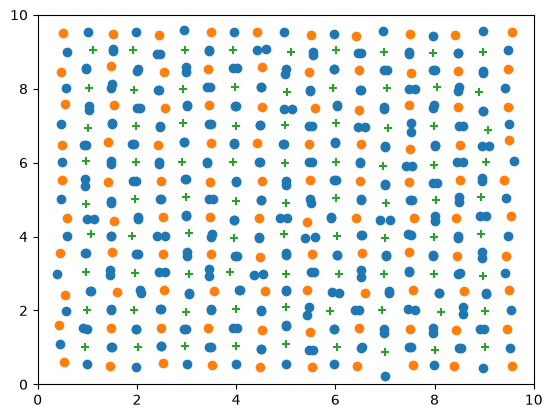

In [153]:
plt.scatter(x=vr.vertices[:, 0], y=vr.vertices[:,1])
plt.scatter(x=coord[:100, 1], y=coord[:100, 2])
plt.scatter(x=coord[100:, 1], y=coord[100:, 2], marker="+")
plt.xlim(0,10)
plt.ylim(0,10)

(array([[ 0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  2.,  0., 56.,
         78., 72., 76., 54.,  0.,  1.,  0.,  1.,  1.,  1.,  0.,  0.,  0.,
          0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  1.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,
          0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0., 50.,
         77., 75., 81., 55.,  0.,  0.,  0.,  0.,  2.,  1.,  1.,  0.,  0.,
          0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.]]),
 array([-50., -48., -46., -44., -42., -40., -38., -36., -34., -32., -30.,
        -28., -26., -24., -22., -20., -18., -16., -14., -12., -10.,  -8.,
         -6.,  -4.,  -2.,   0.,   2.,   4.,   6.,   8.,  10.,  12.,  14.,
         16.,  18.,  20.,  22.,  24.,  26.,  28.,  30.,  32.,  34.,  36.,
         38.,  40.,  42.,  44.,  46.,  48.,  50.]),
 <a list of 2 BarContainer objects>)

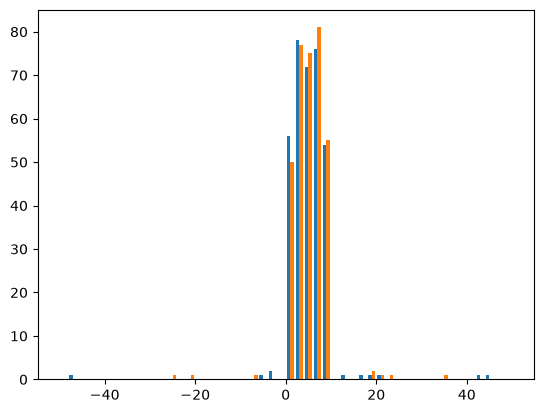

In [154]:
plt.hist(vr.vertices, range= [-50,50], bins=50)

In [155]:
# We won't use voronoy diagram to compute potential energy and force 
# but select the closest neighbors being given a typical distance in which these neighbors fall

In [156]:
neigh_dist = 1. * side_size

def neigh_xy(pos_x = nb_big_side * side_size/2., pos_y = nb_big_side * side_size/2.,coord = coord,
             neigh_dist = neigh_dist, big_f = big_f, small_f = small_f):
    neigh = np.where(np.sqrt(np.square(coord[:,1]-pos_x)+np.square(coord[:,2]-pos_y)) < neigh_dist)
    return neigh

In [157]:
neigh_xy()

(array([ 44,  45,  54,  55, 131, 139, 140, 149]),)

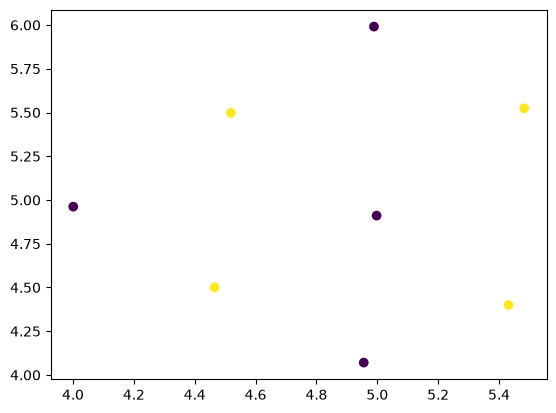

In [158]:
c_map = {1: 'b', 0: 'r'}


plt.scatter(x=coord[neigh_xy(), 1], y=coord[neigh_xy(), 2], c=coord[neigh_xy(), 3])

In [159]:
neigh_dist = 1. * side_size

# Physical force parameters
big_f = 0.1
small_f = 0.05
mass_big = 1
mass_small = 0.5

# testing coordinates
pos_x = nb_big_side * side_size/2.
pos_y = nb_big_side * side_size/2.

def force_xy(pos_x = nb_big_side * side_size/2., pos_y = nb_big_side * side_size/2.,coord = coord,
             neigh_dist = neigh_dist, big_f = big_f, small_f = small_f):
    """ this function determines the force exerted  at a given position by closest neighbors"""

    neigh = np.where(np.sqrt(np.square(coord[:,1]-pos_x)+np.square(coord[:,2]-pos_y)) < neigh_dist)
    
    f_xy = np.zeros([len(neigh[0]), 2])
    
    for partic in range(len(neigh[0])):    
        if coord[neigh[0][partic],3] == 1:
            f_xy[partic] = [big_f * (pos_x - coord[neigh[0][partic],1]), big_f * (pos_y - coord[neigh[0][partic],2])]/(np.square(coord[neigh[0][partic],1]-pos_x)+np.square(coord[neigh[0][partic],2]-pos_y))
        else:
            f_xy[partic] = [small_f * (pos_x - coord[neigh[0][partic],1]), small_f * (pos_y - coord[neigh[0][partic],2])]/(np.square(coord[neigh[0][partic],1]-pos_x)+np.square(coord[neigh[0][partic],2]-pos_y))   

    force_xy = np.sum(f_xy, axis = 0)

    return force_xy

force_xy()

array([0.09337202, 0.56220157])

In [140]:
# not to forget, in case we want to calculate the force exerted on a particle, not taking in account the force of the particle on itself
# partic_index 
# for partic in range(len(neigh[0])): 
#    if coord[neigh[0][partic],0] != partic_index:
# ....
def force_partic(idx_partic = 0, coord = coord,
             neigh_dist = neigh_dist, big_f = big_f, small_f = small_f):
    """ this function determines the force exerted  of a given particle by closest neighbors"""
    pos_x = coord[idx_partic, 1]
    pos_y = coord[idx_partic, 2]

    neigh = np.where(np.sqrt(np.square(coord[:,1]-pos_x)+np.square(coord[:,2]-pos_y)) < neigh_dist)
    
    f_xy = np.zeros([len(neigh[0]), 2])
    
    for partic in range(len(neigh[0])):
        if coord[neigh[0][partic],0] != idx_partic:   
            if coord[neigh[0][partic],3] == 1:
                f_xy[partic] = [big_f * (pos_x - coord[neigh[0][partic],1]), big_f * (pos_y - coord[neigh[0][partic],2])]/(np.square(coord[neigh[0][partic],1]-pos_x)+np.square(coord[neigh[0][partic],2]-pos_y))
            else:
                f_xy[partic] = [small_f * (pos_x - coord[neigh[0][partic],1]), small_f * (pos_y - coord[neigh[0][partic],2])]/(np.square(coord[neigh[0][partic],1]-pos_x)+np.square(coord[neigh[0][partic],2]-pos_y))   

    force_xy = np.sum(f_xy, axis = 0)

    return force_xy

force_partic()

array([-0.16581044, -0.04668456])

In [192]:
# computation of a step of deplacement for a given particle
time_step = 0.1
display(coord[0,:])
def partic_move(idx_partic=0, coord=coord, time_step=time_step):
    speed = [coord[idx_partic, 4], coord[idx_partic, 5]]
    f_xy = force_partic(idx_partic, coord, neigh_dist, big_f, small_f)
    # print(f_xy)
    if coord[idx_partic, 3] == 1.:
        m_partic = mass_big
    else:
        m_partic = mass_small
    speed += f_xy * time_step / m_partic
    coord[idx_partic, 4:] = speed 
    coord[idx_partic, 1:3] += speed * time_step

    return coord

coord_0 = partic_move()
coord_0[0,:]

array([ 0.        ,  0.13000794,  0.37681634,  1.        , -0.06185319,
       -0.04869556])

array([ 0.        ,  0.12382263,  0.37194678,  1.        , -0.06185319,
       -0.04869556])

In [187]:
# test for the dynamics of the 0th particle, should obtain a line slowing
n_step = 10

coord_0 = coord.copy()
coord_time = np.zeros([n_step, 2])
for step_i in range (n_step):
    coord_0 = partic_move(coord=coord_0)
    coord_time[step_i, :] = coord_0[0, 1:3]

coord_time

[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]
[0. 0.]


array([[0.12382263, 0.37194678],
       [0.11763731, 0.36707723],
       [0.11145199, 0.36220767],
       [0.10526667, 0.35733811],
       [0.09908135, 0.35246856],
       [0.09289603, 0.347599  ],
       [0.08671071, 0.34272945],
       [0.08052539, 0.33785989],
       [0.07434007, 0.33299033],
       [0.06815475, 0.32812078]])

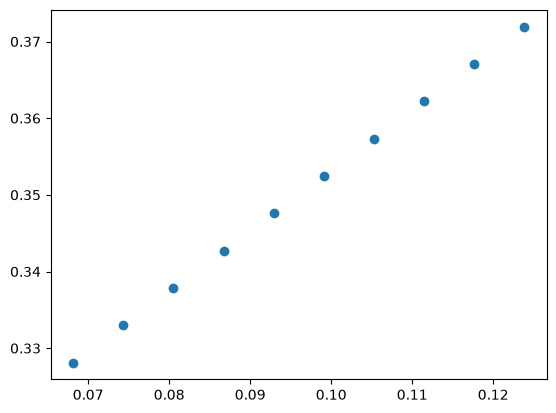

In [188]:
plt.scatter(x=coord_time[:,0], y=coord_time[:,1])

In [189]:
# test for the dynamics of a particle in the core of the sample
n_step = 10
idx_partic = 25

coord_0 = coord.copy()
coord_time = np.zeros([n_step, 2])
for step_i in range (n_step):
    coord_0 = partic_move(idx_partic=idx_partic, coord=coord_0)
    coord_time[step_i, :] = coord_0[idx_partic, 1:3]

coord_time

[ 0.12504207 -0.08110916]
[ 0.12500073 -0.08115007]
[ 0.12491729 -0.08123145]
[ 0.12479021 -0.08135224]
[ 0.12461719 -0.0815103 ]
[ 0.1243952  -0.08170179]
[0.13040397 0.01764887]
[0.12914954 0.01709055]
[0.12773009 0.01658115]
[0.12615799 0.01612763]


array([[5.43386247, 2.54765874],
       [5.4363629 , 2.54603615],
       [5.4401125 , 2.54360124],
       [5.44511   , 2.54035282],
       [5.45135367, 2.53628928],
       [5.4588413 , 2.53140873],
       [5.46763297, 2.52670467],
       [5.47771613, 2.52217152],
       [5.48907659, 2.51780417],
       [5.50169864, 2.5135981 ]])

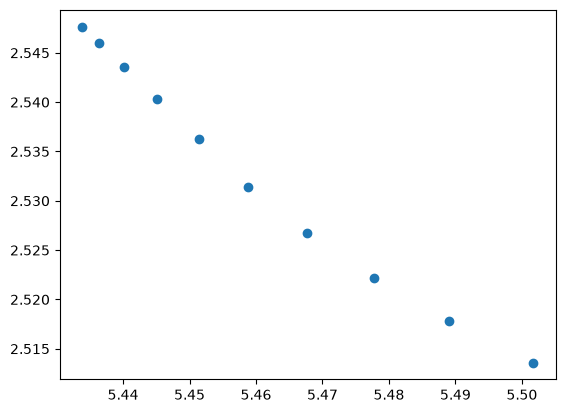

In [190]:
plt.scatter(x=coord_time[:,0], y=coord_time[:,1])

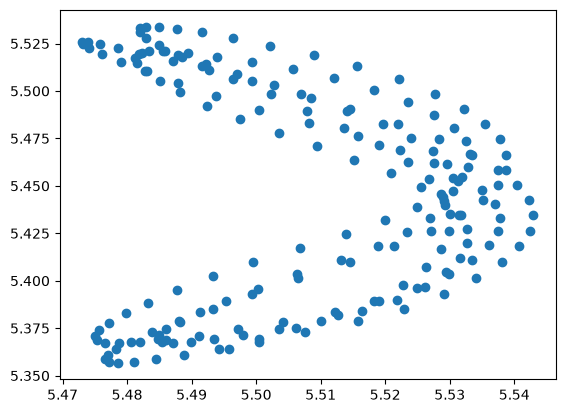

In [198]:

idx_partic = 55
n_step = 200
coord_0 = coord.copy()

def single_partic_traj(idx_partic = idx_partic, n_step = n_step, coord = coord):

    coord_time = np.zeros([n_step, 2])
    for step_i in range (n_step):
        coord_0 = partic_move(idx_partic=idx_partic, coord=coord)
        coord_time[step_i, :] = coord_0[idx_partic, 1:3]

    return coord_time

coord_time=single_partic_traj(coord = coord_0)
plt.scatter(x=coord_time[:,0], y=coord_time[:,1])

In [225]:
n_step = 1
time_step = 1.
coord_0 = coord.copy()
coord_1 = coord.copy()
coord_2 = np.zeros([nb_big + nb_small,4])

def all_partic_1step(coord = coord):

    for idx_partic in range(nb_big + nb_small):
        coord_2 = partic_move(idx_partic=idx_partic, coord=coord_1, time_step=time_step)
        
    return coord_2

coord_2 = all_partic_1step(coord = coord_1)

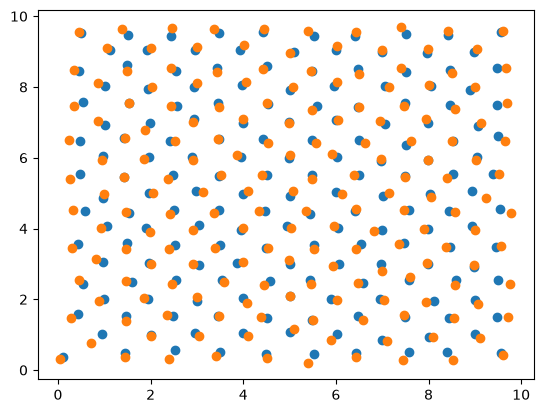

In [226]:
plt.scatter(x=coord_0[:,1], y=coord_0[:,2])
plt.scatter(x=coord_2[:,1], y=coord_2[:,2])